# Visualización con Seaborn: ventajas sobre Matplotlib

[Seaborn](https://seaborn.pydata.org/) es una librería de visualización estadística construida **sobre Matplotlib**. No la reemplaza, sino que la complementa ofreciendo:

| Ventaja de Seaborn | Detalle |
|---|---|
| **Código más conciso** | Un gráfico que requiere 10+ líneas en Matplotlib se logra en 1-2 líneas con Seaborn |
| **Estética superior por defecto** | Paletas de colores profesionales y estilos listos para usar |
| **Integración con DataFrames** | Acepta directamente columnas de `pandas` con el parámetro `data=` |
| **Separación por categorías automática** | Parámetros `hue`, `col` y `row` para dividir gráficos por grupos sin bucles |
| **Gráficos estadísticos nativos** | Violin plots, KDE, pair plots, heatmaps de correlación, etc. |
| **Intervalos de confianza** | Muchas funciones calculan y muestran IC automáticamente |

En este cuaderno replicamos los ejemplos del cuaderno de Matplotlib para **comparar ambas aproximaciones** lado a lado.

## 1. Importar librerías y configurar estilo

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ventaja 1: configurar un estilo profesional en una sola línea
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

## 2. Crear el mismo conjunto de datos

Usamos exactamente los mismos datos que en el cuaderno de Matplotlib para que la comparación sea directa.

In [17]:
np.random.seed(42)
n = 200

df = pd.DataFrame({
    # Variables continuas
    "estatura_cm": np.random.normal(loc=168, scale=10, size=n).round(1),
    "peso_kg": np.random.normal(loc=68, scale=12, size=n).round(1),
    "promedio_notas": np.random.uniform(low=2.5, high=5.0, size=n).round(2),
    # Variables discretas
    "num_materias": np.random.poisson(lam=5, size=n),
    "num_hermanos": np.random.choice([0, 1, 2, 3, 4, 5], size=n, p=[0.10, 0.25, 0.30, 0.20, 0.10, 0.05]),
    "horas_estudio_semana": np.random.randint(low=2, high=25, size=n),
    # Variables categóricas
    "genero": np.random.choice(["Femenino", "Masculino", "Otro"], size=n, p=[0.50, 0.45, 0.05]),
    "estrato": np.random.choice([1, 2, 3, 4, 5, 6], size=n, p=[0.05, 0.15, 0.35, 0.25, 0.15, 0.05]),
    "carrera": np.random.choice(
        ["Ingeniería", "Medicina", "Derecho", "Economía", "Psicología"],
        size=n, p=[0.25, 0.15, 0.20, 0.20, 0.20]),
})

df["genero"] = df["genero"].astype("category")
df["estrato"] = df["estrato"].astype("category")
df["carrera"] = df["carrera"].astype("category")

df.head()

,estatura_cm,peso_kg,promedio_notas,num_materias,num_hermanos,horas_estudio_semana,genero,estrato,carrera
0,173.0,72.3,3.54,3,2,17,Masculino,3,Medicina
1,166.6,74.7,3.18,6,2,2,Masculino,3,Ingeniería
2,174.5,81.0,2.64,7,3,14,Masculino,1,Economía
3,183.2,80.6,4.66,8,0,24,Femenino,3,Economía
4,165.7,51.5,4.53,6,2,22,Masculino,3,Medicina


---

## 3. Variables Continuas

### 3.1 Histograma con KDE superpuesto

> **Ventaja**: `sns.histplot` dibuja el histograma **y** la curva de densidad KDE en una sola llamada con `kde=True`. En Matplotlib se necesita código adicional con `scipy` o cálculos manuales.

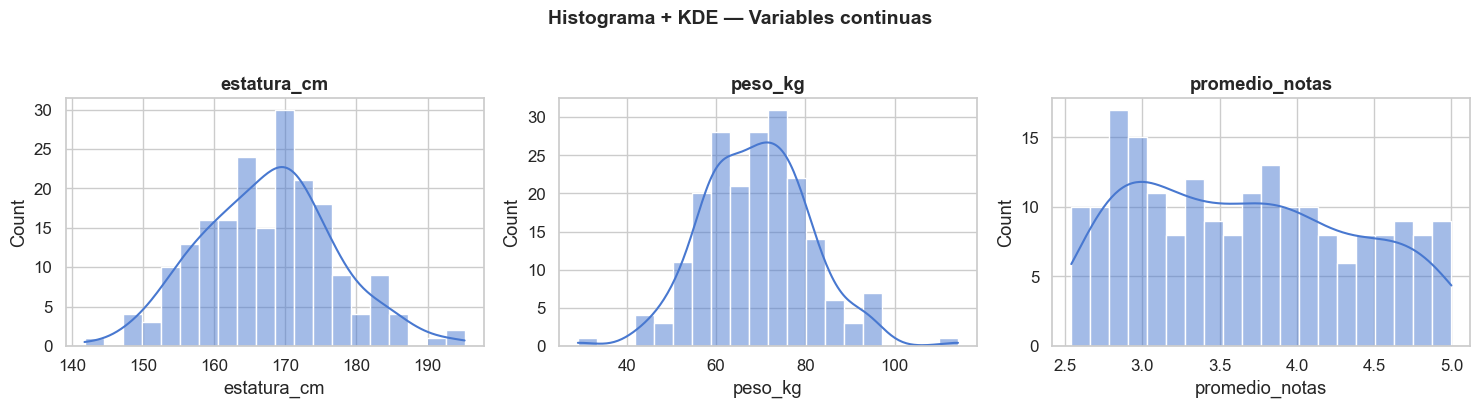

In [18]:
# En Matplotlib: plt.hist() + cálculo manual de KDE → ~15 líneas
# En Seaborn: una sola línea por variable

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
vars_continuas = ["estatura_cm", "peso_kg", "promedio_notas"]

for ax, var in zip(axes, vars_continuas):
    sns.histplot(data=df, x=var, kde=True, bins=20, ax=ax)
    ax.set_title(var, fontweight="bold")

fig.suptitle("Histograma + KDE — Variables continuas", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 3.2 Boxplot

> **Ventaja**: `sns.boxplot` acepta directamente un DataFrame con `data=` y asigna colores por paleta automáticamente. No hay que crear listas de datos manualmente ni colorear cada caja en un bucle.

/var/folders/tf/x2jqms8n4wn8gfljd87ypbl40000gn/T/ipykernel_21815/1591287057.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_continuas, x="Variable", y="Valor", palette="Set2", ax=ax)


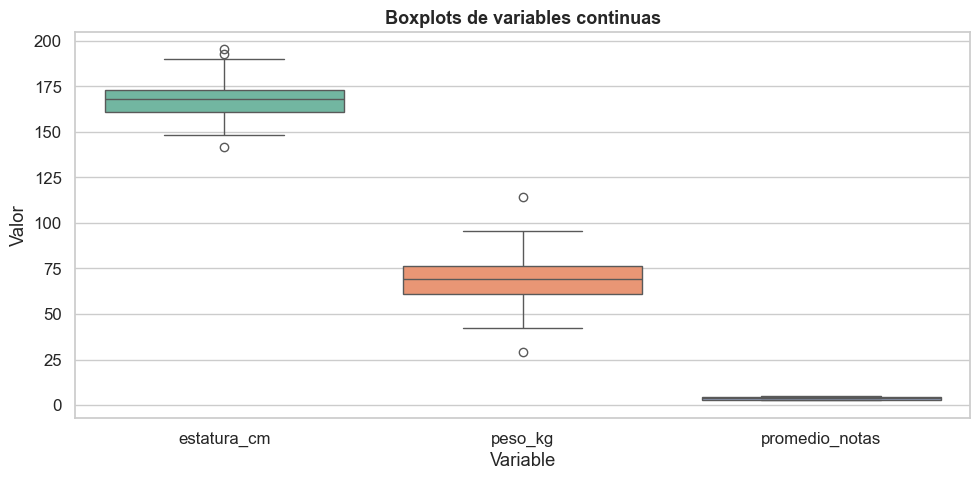

In [19]:
# Transformar a formato largo para graficar las 3 variables juntas
df_continuas = df[vars_continuas].melt(var_name="Variable", value_name="Valor")

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_continuas, x="Variable", y="Valor", palette="Set2", ax=ax)
ax.set_title("Boxplots de variables continuas", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

### 3.3 Violin plot (exclusivo de Seaborn)

> **Ventaja**: El violin plot **no existe en Matplotlib básico**. Combina un boxplot con una estimación de densidad KDE simétrica, mostrando la forma completa de la distribución.

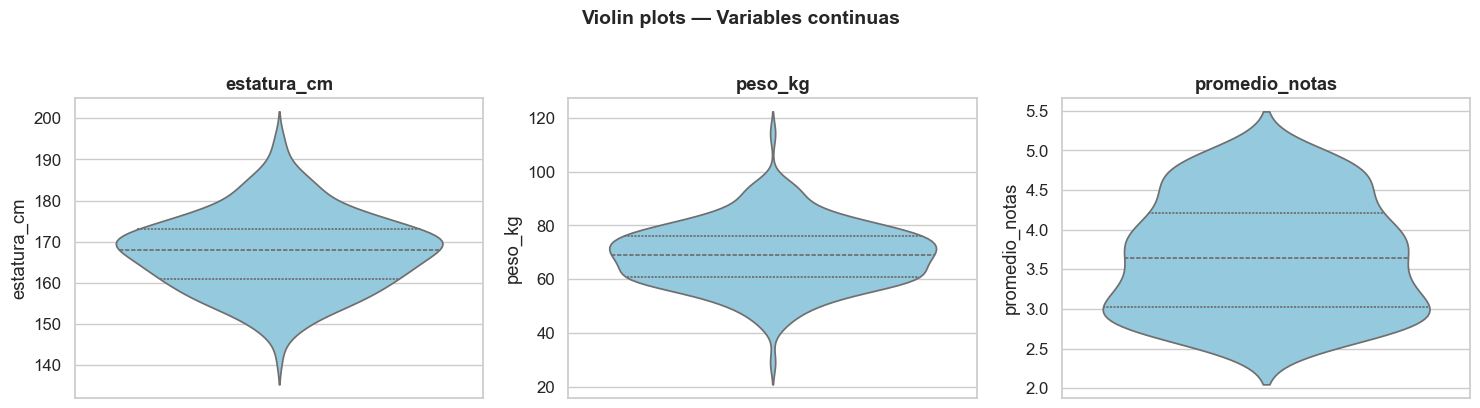

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, var in zip(axes, vars_continuas):
    sns.violinplot(data=df, y=var, inner="quartile", color="skyblue", ax=ax)
    ax.set_title(var, fontweight="bold")

fig.suptitle("Violin plots — Variables continuas", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 3.4 Scatter plot con regresión

> **Ventaja**: `sns.regplot` y `sns.lmplot` agregan automáticamente la **línea de regresión + intervalo de confianza** al gráfico de dispersión. En Matplotlib hay que calcular la regresión con `numpy` o `scipy` manualmente.

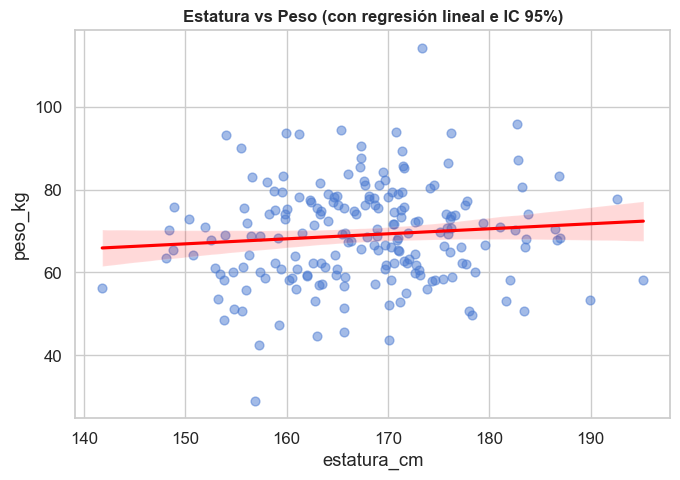

In [21]:
# En Matplotlib: scatter + np.polyfit + plt.plot → ~10 líneas
# En Seaborn: una sola función

fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(data=df, x="estatura_cm", y="peso_kg",
            scatter_kws={"alpha": 0.5, "s": 40},
            line_kws={"color": "red"},
            ax=ax)
ax.set_title("Estatura vs Peso (con regresión lineal e IC 95%)", fontweight="bold", fontsize=12)
plt.tight_layout()
plt.show()

---

## 4. Variables Discretas

### 4.1 Gráfico de conteo

> **Ventaja**: `sns.countplot` cuenta automáticamente las frecuencias de cada valor. En Matplotlib primero hay que calcular `value_counts()` y luego pasar los datos a `plt.bar()`.

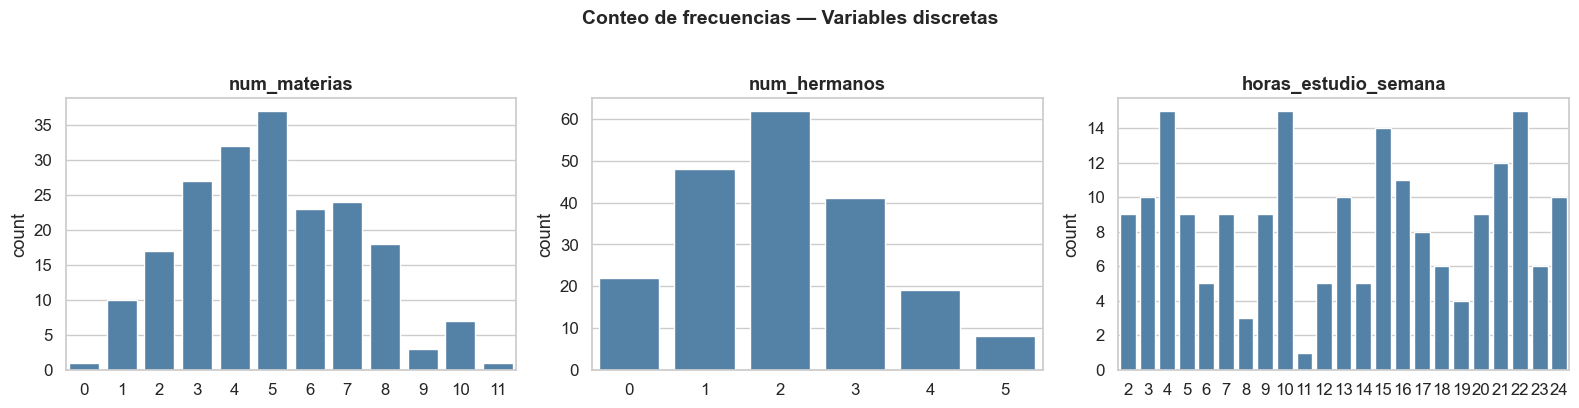

In [22]:
vars_discretas = ["num_materias", "num_hermanos", "horas_estudio_semana"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, var in zip(axes, vars_discretas):
    sns.countplot(data=df, x=var, color="steelblue", ax=ax)
    ax.set_title(var, fontweight="bold")
    ax.set_xlabel("")

fig.suptitle("Conteo de frecuencias — Variables discretas", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 4.2 Histograma discreto con estadístico

> **Ventaja**: `sns.histplot` con `discrete=True` ajusta automáticamente los bins para que estén centrados en cada valor entero.

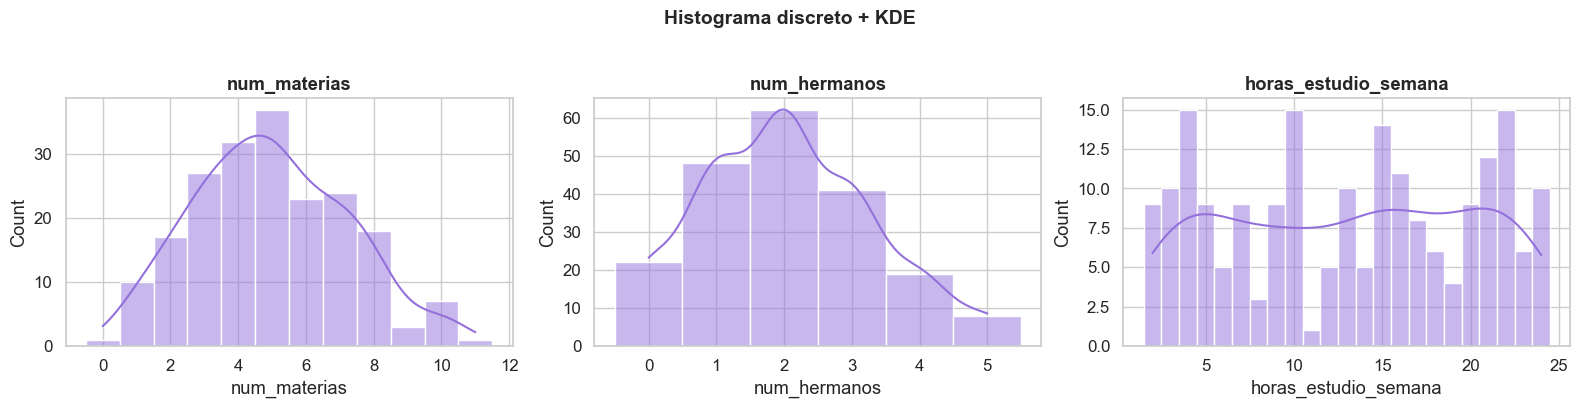

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, var in zip(axes, vars_discretas):
    sns.histplot(data=df, x=var, discrete=True, kde=True,
                 color="mediumpurple", ax=ax)
    ax.set_title(var, fontweight="bold")

fig.suptitle("Histograma discreto + KDE", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 4.3 Strip plot (exclusivo de Seaborn)

> **Ventaja**: El strip plot muestra **cada observación individual** como un punto. Es especialmente útil para variables discretas con pocos valores, donde un histograma puede ocultar la densidad real.

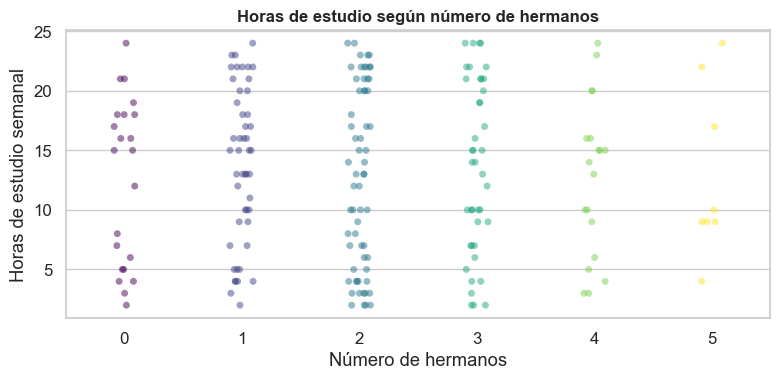

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.stripplot(data=df, x="num_hermanos", y="horas_estudio_semana",
              jitter=True, alpha=0.5, palette="viridis", hue="num_hermanos",
              legend=False, ax=ax)
ax.set_title("Horas de estudio según número de hermanos", fontweight="bold", fontsize=12)
ax.set_xlabel("Número de hermanos")
ax.set_ylabel("Horas de estudio semanal")
plt.tight_layout()
plt.show()

---

## 5. Variables Categóricas

### 5.1 Gráfico de conteo con `hue`

> **Ventaja**: El parámetro `hue` permite **separar por colores** una segunda variable categórica sin escribir bucles ni código adicional. En Matplotlib esto requiere múltiples llamadas a `plt.bar` con offsets calculados manualmente.

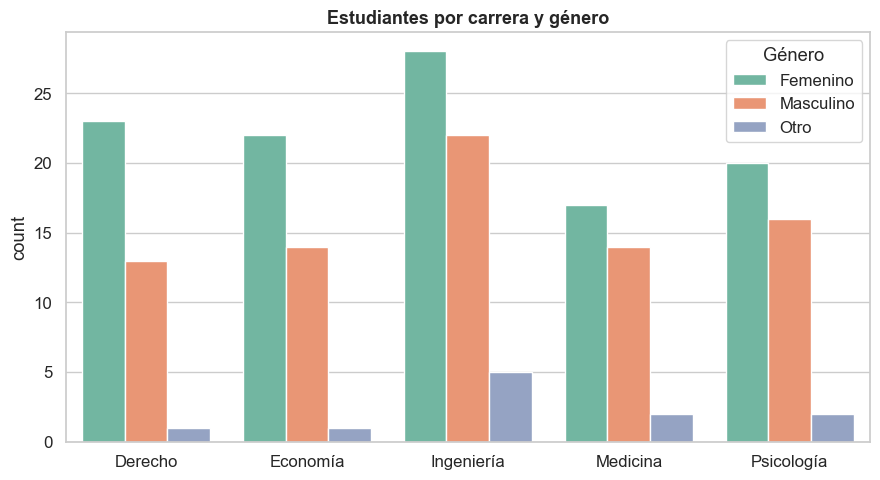

In [25]:
# Conteo de carrera, separado por género — una sola línea
fig, ax = plt.subplots(figsize=(9, 5))
sns.countplot(data=df, x="carrera", hue="genero", palette="Set2", ax=ax)
ax.set_title("Estudiantes por carrera y género", fontweight="bold", fontsize=13)
ax.set_xlabel("")
ax.legend(title="Género")
plt.tight_layout()
plt.show()

### 5.2 Gráfico de barras con estimador estadístico

> **Ventaja**: `sns.barplot` calcula automáticamente la **media** (u otro estimador) y muestra **barras de error** (intervalo de confianza). En Matplotlib hay que calcular medias, errores estándar y pasarlos manualmente.

/var/folders/tf/x2jqms8n4wn8gfljd87ypbl40000gn/T/ipykernel_21815/159572224.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="carrera", y="promedio_notas", palette="coolwarm",


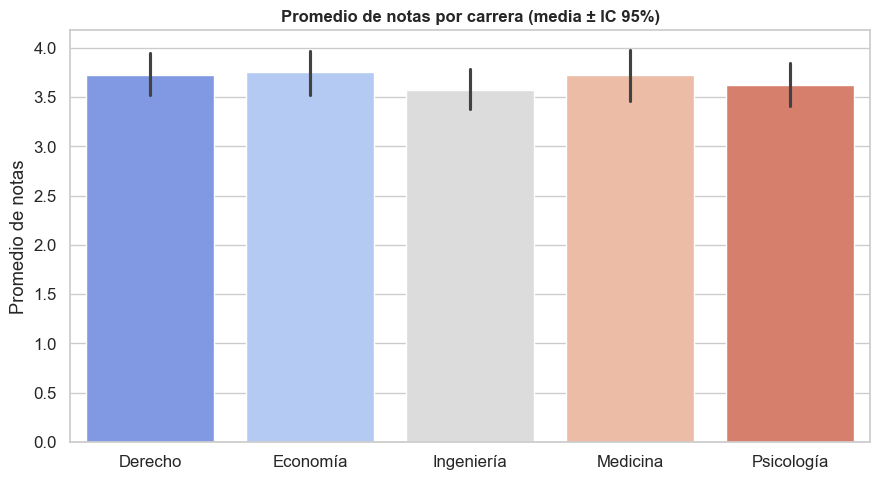

In [26]:
# Media del promedio de notas por carrera, con IC 95% automático
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=df, x="carrera", y="promedio_notas", palette="coolwarm",
            errorbar="ci", ax=ax)
ax.set_title("Promedio de notas por carrera (media ± IC 95%)", fontweight="bold", fontsize=12)
ax.set_xlabel("")
ax.set_ylabel("Promedio de notas")
plt.tight_layout()
plt.show()

### 5.3 Pie chart

Seaborn **no tiene función propia para gráficos circulares**, ya que generalmente se desaconsejan para análisis estadístico (las longitudes de arco son más difíciles de comparar que las alturas de barras). Para este caso seguimos usando `matplotlib.pyplot.pie`.

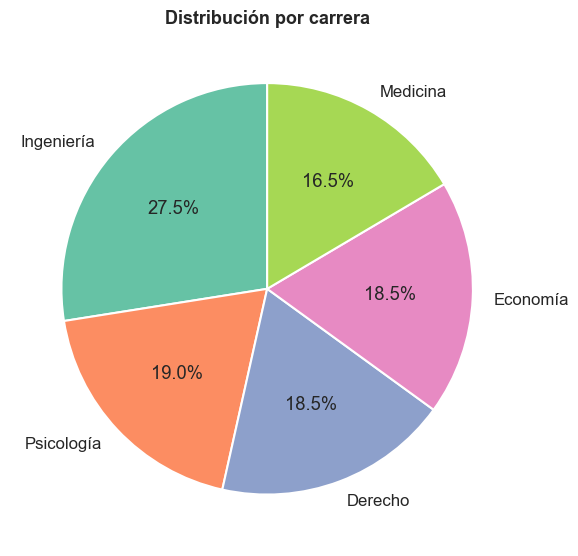

In [27]:
# Pie chart con la paleta de colores de Seaborn
colores = sns.color_palette("Set2", n_colors=df["carrera"].nunique())

fig, ax = plt.subplots(figsize=(6, 6))
conteos = df["carrera"].value_counts()
ax.pie(conteos.values, labels=conteos.index, autopct="%1.1f%%",
       colors=colores, startangle=90,
       wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax.set_title("Distribución por carrera", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

---

## 6. Análisis cruzado: la gran fortaleza de Seaborn

### 6.1 Boxplot por categoría

> **Ventaja**: Separar un boxplot por categoría es directamente `x="categoría"`, `y="numérica"`. En Matplotlib hay que filtrar datos y construir listas manualmente.

/var/folders/tf/x2jqms8n4wn8gfljd87ypbl40000gn/T/ipykernel_21815/1531949462.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="carrera", y="promedio_notas", palette="Set3", ax=ax)


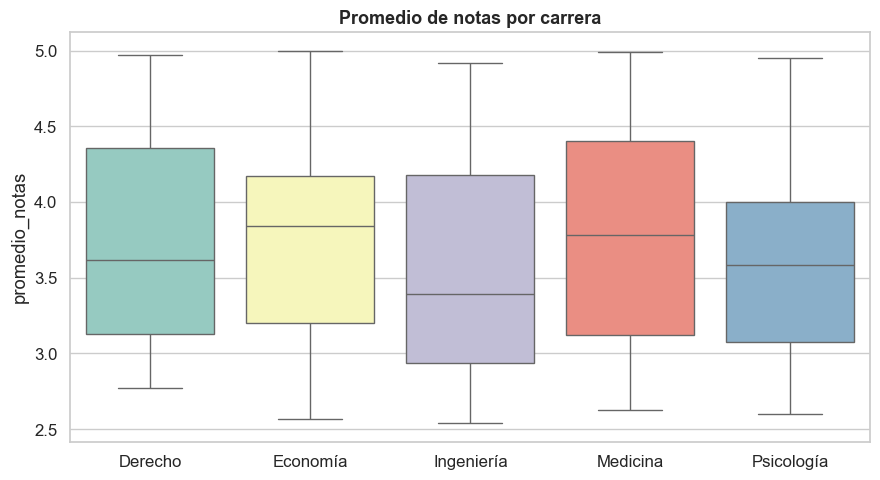

In [28]:
# En Matplotlib: filtrar datos por carrera, crear lista, colorear cada caja → ~18 líneas
# En Seaborn: una línea

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="carrera", y="promedio_notas", palette="Set3", ax=ax)
ax.set_title("Promedio de notas por carrera", fontweight="bold", fontsize=13)
ax.set_xlabel("")
plt.tight_layout()
plt.show()

### 6.2 Violin plot por categoría con `hue`

> **Ventaja**: Combinar una variable numérica, una categórica en el eje x, y otra categórica con `hue` requiere una sola línea. Intente reproducir esto con Matplotlib puro.

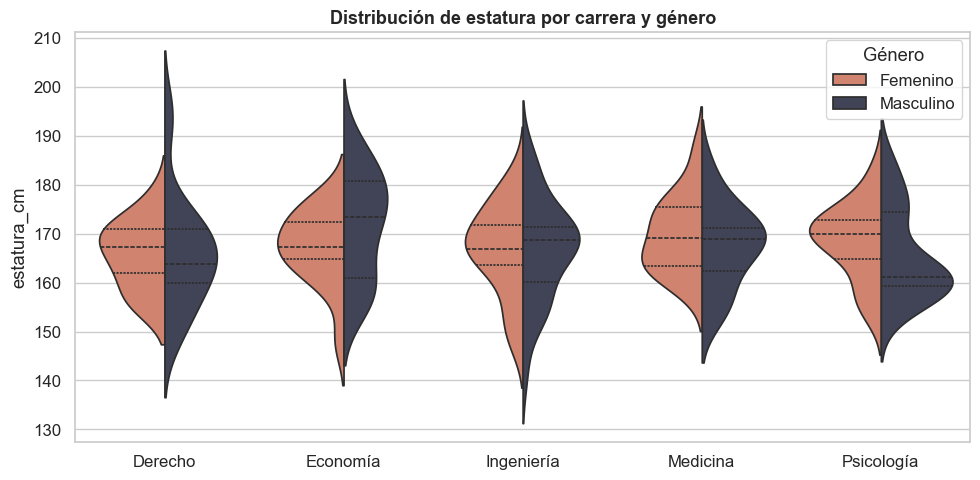

In [29]:
# Filtrar solo Femenino y Masculino para mejor lectura visual
df_fm = df[df["genero"].isin(["Femenino", "Masculino"])].copy()
df_fm["genero"] = df_fm["genero"].cat.remove_unused_categories()

fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(data=df_fm, x="carrera", y="estatura_cm", hue="genero",
               split=True, inner="quartile", palette={"Femenino": "#E07A5F", "Masculino": "#3D405B"},
               ax=ax)
ax.set_title("Distribución de estatura por carrera y género", fontweight="bold", fontsize=13)
ax.set_xlabel("")
ax.legend(title="Género")
plt.tight_layout()
plt.show()

### 6.3 Histogramas superpuestos con `hue`

> **Ventaja**: En Matplotlib se necesita un bucle para superponer histogramas por grupo. En Seaborn basta con `hue="genero"`.

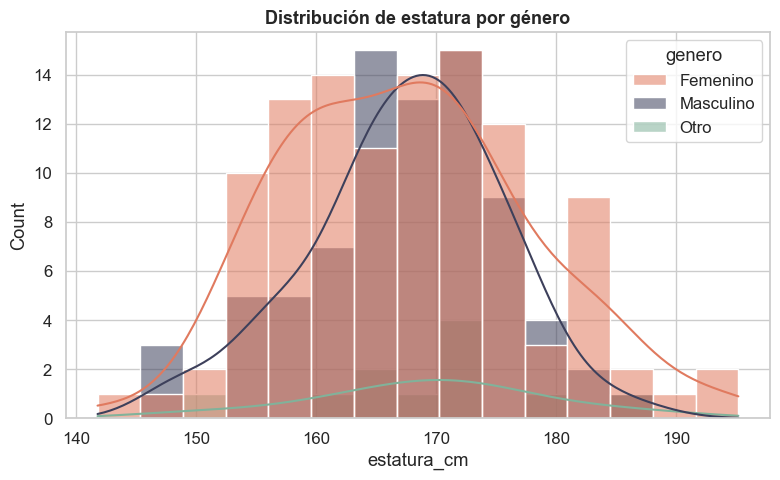

In [30]:
# En Matplotlib: bucle por género + plt.hist() con alpha → ~8 líneas
# En Seaborn: una sola línea

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=df, x="estatura_cm", hue="genero", bins=15,
             alpha=0.55, kde=True, palette=["#E07A5F", "#3D405B", "#81B29A"], ax=ax)
ax.set_title("Distribución de estatura por género", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

---

## 7. Gráficos exclusivos de Seaborn

Estas visualizaciones **no existen en Matplotlib** y requieren Seaborn (o mucho código manual).

### 7.1 Pair plot

El pair plot genera una **matriz de gráficos de dispersión** para todas las combinaciones de variables numéricas y la diagonal muestra la distribución de cada una.

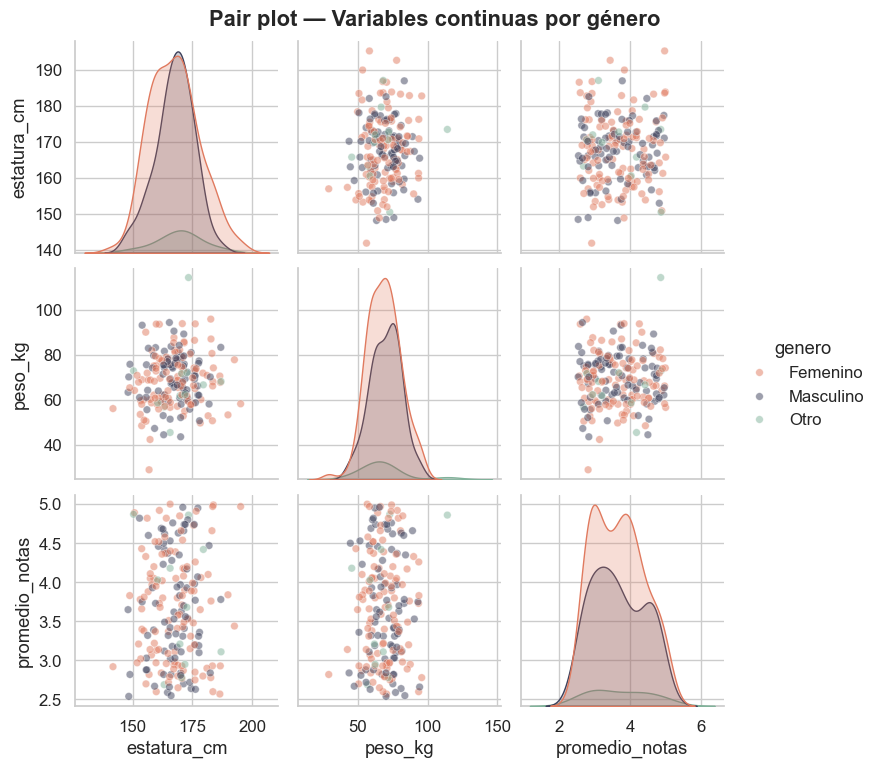

In [31]:
# Una sola línea genera N×N gráficos con separación por color
sns.pairplot(df[["estatura_cm", "peso_kg", "promedio_notas", "genero"]],
             hue="genero", palette={"Femenino": "#E07A5F", "Masculino": "#3D405B", "Otro": "#81B29A"},
             diag_kind="kde", plot_kws={"alpha": 0.5, "s": 30})
plt.suptitle("Pair plot — Variables continuas por género", fontweight="bold", y=1.02)
plt.show()

### 7.2 Heatmap de correlación

El heatmap colorea una **matriz de correlación** para identificar rápidamente relaciones fuertes entre variables.

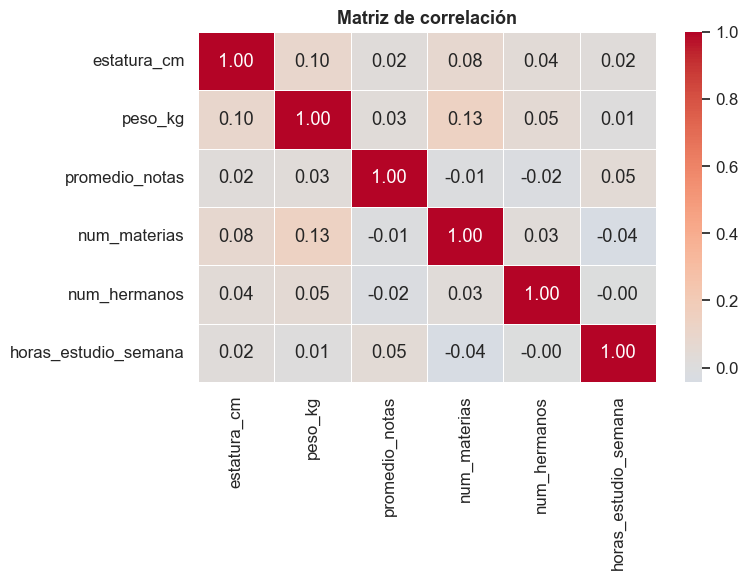

In [32]:
vars_numericas = ["estatura_cm", "peso_kg", "promedio_notas",
                  "num_materias", "num_hermanos", "horas_estudio_semana"]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df[vars_numericas].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5, ax=ax)
ax.set_title("Matriz de correlación", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

### 7.3 FacetGrid: grilla de subgráficos por categoría

> **Ventaja**: `FacetGrid` (o los parámetros `col` y `row`) generan automáticamente un subgráfico por cada valor de una variable categórica. Reproducir esto en Matplotlib requiere gestionar subplots manualmente.

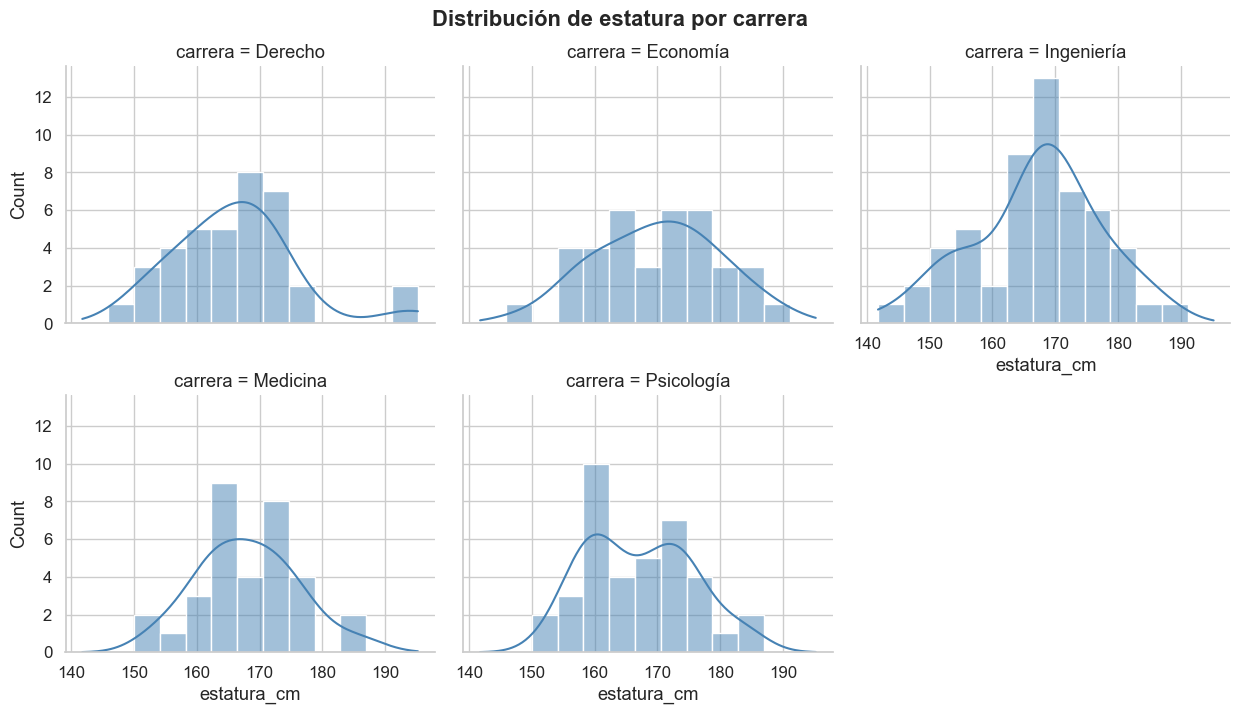

In [33]:
# Histograma de estatura, un panel por cada carrera
g = sns.displot(data=df, x="estatura_cm", col="carrera", col_wrap=3,
                kde=True, height=3.5, aspect=1.2, color="steelblue")
g.fig.suptitle("Distribución de estatura por carrera", fontweight="bold", y=1.02)
plt.show()

### 7.4 Joint plot: distribuciones marginales

El joint plot combina un scatter (o KDE) con los histogramas marginales de cada eje en un solo gráfico.

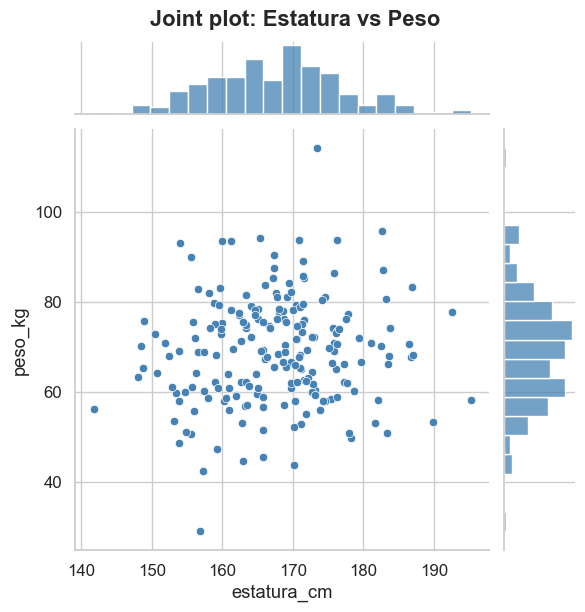

In [34]:
sns.jointplot(data=df, x="estatura_cm", y="peso_kg",
              kind="scatter", marginal_kws={"bins": 20},
              height=6, color="steelblue")
plt.suptitle("Joint plot: Estatura vs Peso", fontweight="bold", y=1.02)
plt.show()

---

## 8. Combinando Seaborn + Matplotlib: ajustes finos

Como Seaborn genera objetos de Matplotlib (`Figure`, `Axes`), podemos usar **toda la API de Matplotlib** para personalizar el gráfico después de crearlo. Este es el flujo recomendado en la práctica:

1. **Seaborn** genera la base del gráfico (datos, colores, estadísticas).
2. **Matplotlib** ajusta detalles: anotaciones, líneas de referencia, formato de ejes, leyendas personalizadas, etc.

/var/folders/tf/x2jqms8n4wn8gfljd87ypbl40000gn/T/ipykernel_21815/881844722.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="carrera", y="promedio_notas", palette="Set2",


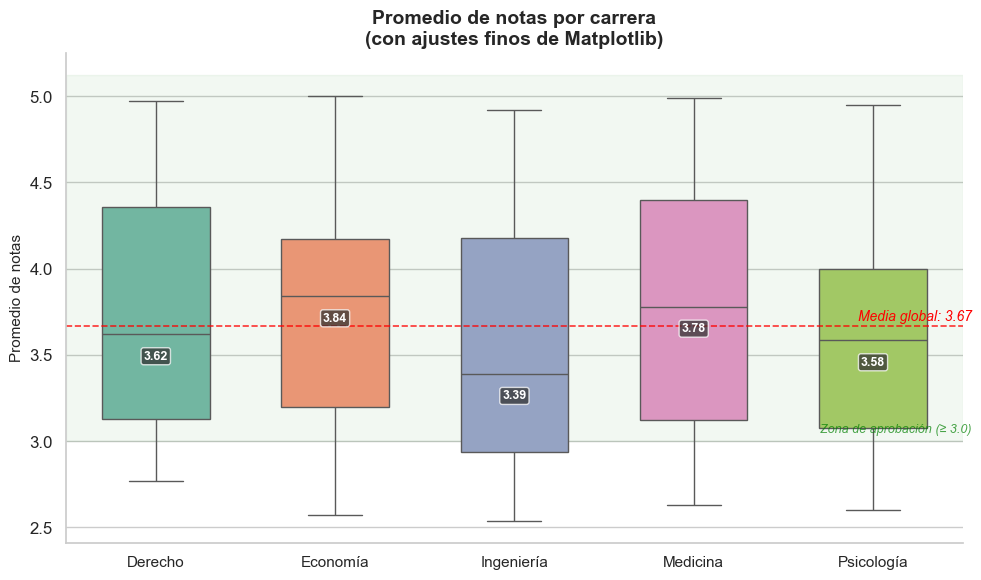

In [35]:
# --- Paso 1: Seaborn genera el gráfico base ---
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x="carrera", y="promedio_notas", palette="Set2",
            width=0.6, ax=ax)

# --- Paso 2: Ajustes finos con Matplotlib ---

# Línea de referencia horizontal (promedio general)
media_global = df["promedio_notas"].mean()
ax.axhline(y=media_global, color="red", linestyle="--", linewidth=1.2, alpha=0.8)
ax.text(4.55, media_global + 0.03, f"Media global: {media_global:.2f}",
        color="red", fontsize=10, fontstyle="italic", ha="right")

# Anotar la mediana de cada carrera sobre cada caja
medianas = df.groupby("carrera")["promedio_notas"].median()
for i, carrera in enumerate(ax.get_xticklabels()):
    nombre = carrera.get_text()
    med = medianas[nombre]
    ax.annotate(f"{med:.2f}",
                xy=(i, med), xytext=(0, -18),
                textcoords="offset points", ha="center",
                fontsize=9, fontweight="bold", color="white",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="#333", alpha=0.75))

# Sombrear zona de "aprobación" (nota ≥ 3.0)
ax.axhspan(3.0, ax.get_ylim()[1], color="green", alpha=0.05)
ax.text(4.55, 3.05, "Zona de aprobación (≥ 3.0)", color="green",
        fontsize=9, fontstyle="italic", ha="right", alpha=0.7)

# Personalización de ejes y formato
ax.set_title("Promedio de notas por carrera\n(con ajustes finos de Matplotlib)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Promedio de notas", fontsize=11)
ax.tick_params(axis="x", labelsize=11, rotation=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

En este ejemplo, **Seaborn** se encargó de:
- Calcular los cuartiles, medianas y outliers del boxplot
- Asignar colores automáticamente con `palette="Set2"`
- Integrar el DataFrame directamente con `data=df`

Mientras que **Matplotlib** aportó los ajustes finos:
- `ax.axhline()` → línea de referencia de la media global
- `ax.annotate()` → etiquetas de mediana con fondo oscuro sobre cada caja
- `ax.axhspan()` → sombreado de zona de aprobación
- `ax.text()` → anotaciones de texto libre
- `ax.spines[...].set_visible(False)` → eliminar bordes innecesarios

Esta combinación es la forma más productiva de trabajar: **rapidez de Seaborn + control total de Matplotlib**.

---

## 9. Comparación resumida: Matplotlib vs Seaborn

| Aspecto | Matplotlib | Seaborn |
|---|---|---|
| **Histograma + KDE** | `plt.hist()` + cálculo KDE manual | `sns.histplot(kde=True)` |
| **Boxplot por categoría** | Filtrar datos + bucle + colorear cajas | `sns.boxplot(x=cat, y=num)` |
| **Scatter + regresión** | `plt.scatter()` + `np.polyfit` + `plt.plot` | `sns.regplot()` (con IC automático) |
| **Barras agrupadas** | Calcular offsets + múltiples `plt.bar` | `sns.countplot(hue=...)` |
| **Histogramas por grupo** | Bucle por cada grupo | `sns.histplot(hue=...)` |
| **Violin plot** | No disponible nativo | `sns.violinplot()` |
| **Pair plot** | N×N subplots manuales | `sns.pairplot()` |
| **Heatmap** | `plt.imshow()` + anotaciones manuales | `sns.heatmap(annot=True)` |
| **FacetGrid** | Gestión manual de subplots | `col=` / `row=` en funciones figure-level |
| **Joint plot** | No disponible nativo | `sns.jointplot()` |
| **Pie chart** | `plt.pie()` | No disponible (usa `plt.pie()`) |
| **Personalización fina** | Control total sobre cada elemento | Menos flexible (pero usa Matplotlib debajo) |

### Conclusión

- **Seaborn** es ideal para **exploración rápida** y visualización estadística: menos código, mejores defaults, separación por grupos automática.
- **Matplotlib** ofrece **control total** sobre cada elemento del gráfico: esencial para personalizaciones muy específicas o gráficos no estadísticos.
- En la práctica se usan **juntos**: Seaborn para generar la base del gráfico y Matplotlib para ajustes finos posteriores.